# Step 1 — Load & Inspect

We load the CSV data, print basic metadata (shape, information, missing values), and inspect the target variable distribution and overall default rate.


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/nimishwadhwa06/dataset/Loan_Default.csv')
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nMissing Values per Column:")
print(df.isnull().sum())
status_counts = df['Status'].value_counts()
default_rate = df['Status'].mean()
print(f"\nStatus Value Counts:\n{status_counts}")
print(f"Default Rate: {default_rate:.2%}")


Dataset Shape: (148670, 34)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null 

# Exploratory Data Analysis (EDA) Charts

We present 5 basic plots to understand variable distributions and relationships with `Status`:
1. **Distribution of Target Variable**: Visualization of the class imbalance.
2. **Loan Amount Distribution by Status**: Shows differences in requested loan amounts between defaults and non-defaults.
3. **Credit Score by Status**: Details the credit rating spread of applicants.
4. **Income by Status**: Uses log-scaling to compare borrower income groups.
5. **Loan Status by Region**: Evaluates geographical differences in default rates.


/tmp/ipykernel_58/2980084519.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_58/2980084519.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Credit_Score', data=df, ax=axes[1, 0], palette='pastel')
/tmp/ipykernel_58/2980084519.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='income', data=df, ax=axes[1, 1], palette='pastel')


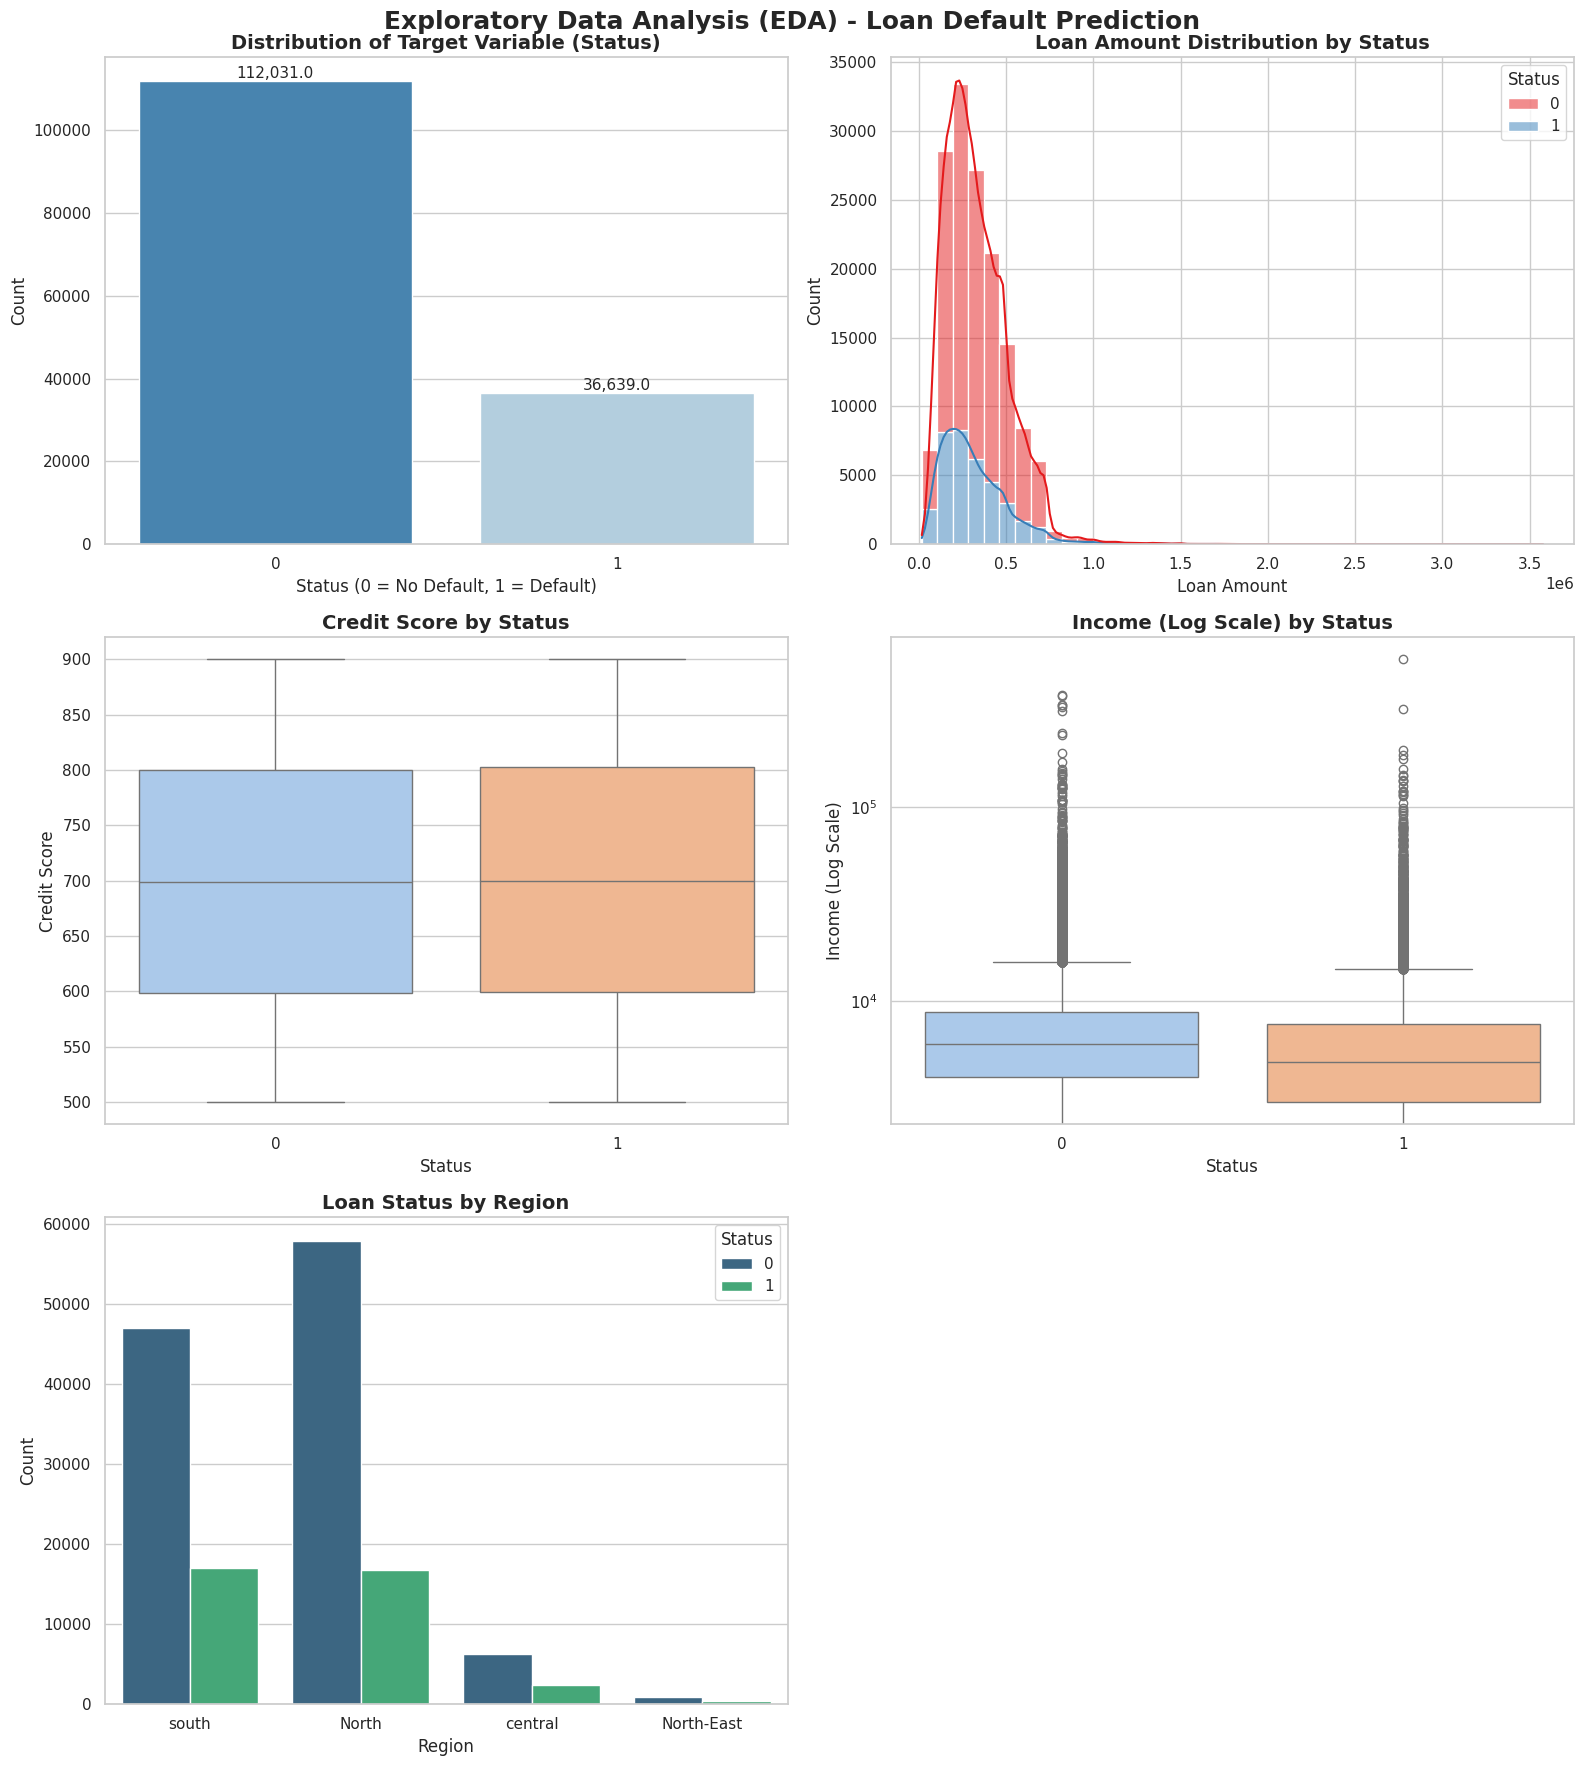

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Exploratory Data Analysis (EDA) - Loan Default Prediction", fontsize=18, fontweight='bold', y=0.98)

sns.countplot(x='Status', data=df, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Distribution of Target Variable (Status)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Status (0 = No Default, 1 = Default)', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

sns.histplot(x='loan_amount', hue='Status', data=df, ax=axes[0, 1], kde=True, bins=40, palette='Set1', multiple='stack')
axes[0, 1].set_title('Loan Amount Distribution by Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Loan Amount', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)

sns.boxplot(x='Status', y='Credit_Score', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Credit Score by Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Status', fontsize=12)
axes[1, 0].set_ylabel('Credit Score', fontsize=12)

sns.boxplot(x='Status', y='income', data=df, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Income (Log Scale) by Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Status', fontsize=12)
axes[1, 1].set_ylabel('Income (Log Scale)', fontsize=12)

sns.countplot(x='Region', hue='Status', data=df, ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('Loan Status by Region', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Region', fontsize=12)
axes[2, 0].set_ylabel('Count', fontsize=12)

fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()


# Step 2 — Leakage Check

A feature is leaky if its value would not be known at the moment the loan application is submitted (i.e., it was set during or after underwriting/approval).

We drop these columns as leaky for the following reasons:
- `rate_of_interest` — final priced interest rate, set after risk assessment
- `Interest_rate_spread` — risk-based pricing spread, tied to the final approval decision
- `Upfront_charges` — fees set based on assessed credit and default risk
- `term` — final agreed term, set during loan structuring
- `Neg_ammortization` — negative amortization status, set during loan structuring
- `interest_only` — interest-only feature, set during loan structuring
- `lump_sum_payment` — lump sum payment feature, set during loan structuring
- `LTV` — Loan-to-Value ratio depends on final approved loan amount and appraised property value, which is determined post-decision
- `dtir1` — debt-to-income ratio is finalized post-underwriting in this dataset
- `Credit_Worthiness` — this is an underwriting output, not a pre-decision input
- `approv_in_adv` — approval-stage flag representing whether the loan was approved in advance
- `credit_type` — credit verification-stage field
- `co-applicant_credit_type` — co-applicant credit verification-stage field
- `ID` — not predictive, just a unique row identifier

Everything else is kept as pre-decision signal.


In [19]:
leakage_cols = [
    'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 
    'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'LTV', 
    'dtir1', 'Credit_Worthiness', 'approv_in_adv', 'credit_type', 
    'co-applicant_credit_type', 'ID'
]
df = df.drop(columns=leakage_cols)
print("Remaining columns after dropping leakage:\n", df.columns.tolist())
print("\nNew shape:", df.shape)


Remaining columns after dropping leakage:
 ['year', 'loan_limit', 'Gender', 'loan_type', 'loan_purpose', 'open_credit', 'business_or_commercial', 'loan_amount', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'Credit_Score', 'age', 'submission_of_application', 'Region', 'Security_Type', 'Status']

New shape: (148670, 20)


# Step 3 — Basic Cleaning

We clean the remaining pre-decision columns simple and cleanly:
- **Numeric columns**: Imputed using column-wise median.
- **Categorical columns**: Imputed using column-wise mode (most frequent value).

No outliers are removed, and no transforms are applied to keep the flow direct.


In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Status', errors='ignore')
cat_cols = df.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
year                         0
loan_limit                   0
Gender                       0
loan_type                    0
loan_purpose                 0
open_credit                  0
business_or_commercial       0
loan_amount                  0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
Credit_Score                 0
age                          0
submission_of_application    0
Region                       0
Security_Type                0
Status                       0
dtype: int64


# Step 4 — Encoding

We convert all remaining categorical variables to numeric format using one-hot encoding (`pd.get_dummies`) with `drop_first=True` to avoid multicollinearity. We verify dataframe shape before and after encoding.


In [21]:
print("Shape before encoding:", df.shape)
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
print("Shape after encoding:", df_encoded.shape)


Shape before encoding: (148670, 20)
Shape after encoding: (148670, 35)


# Step 5 — Feature Selection

We fit a Random Forest Classifier (`n_estimators=100, random_state=42`) on all encoded features against the target `Status`. We use `feature_importances_` to select the top 25 most predictive features and display them ranked by importance.


In [22]:
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop(columns=['Status'])
y = df_encoded['Status']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top_25_features = feat_imp.head(25).index.tolist()

print("Top 25 Features ranked by importance:")
for i, (feat, val) in enumerate(feat_imp.head(25).items(), 1):
    print(f"{i}. {feat}: {val:.6f}")


Top 25 Features ranked by importance:
1. property_value: 0.349522
2. income: 0.182271
3. loan_amount: 0.160819
4. Credit_Score: 0.158369
5. submission_of_application_to_inst: 0.011660
6. loan_purpose_p3: 0.009898
7. age_45-54: 0.009762
8. loan_purpose_p4: 0.009477
9. Gender_Male: 0.008840
10. age_55-64: 0.008827
11. Region_south: 0.008725
12. age_35-44: 0.008164
13. loan_type_type3: 0.007983
14. age_65-74: 0.007531
15. Gender_Joint: 0.006905
16. loan_limit_ncf: 0.006864
17. Region_central: 0.006088
18. Gender_Sex Not Available: 0.005342
19. occupancy_type_pr: 0.005255
20. age_>74: 0.004517
21. loan_type_type2: 0.004199
22. business_or_commercial_nob/c: 0.004057
23. loan_purpose_p2: 0.003102
24. total_units_2U: 0.002727
25. Region_North-East: 0.002153


# Step 6 — Train/Val Split

We split the selected top-25 features dataset into training (80%) and validation (20%) sets. We use `stratify=y` to ensure that class balance is preserved in both sets, and check the default rates.


In [23]:
from sklearn.model_selection import train_test_split

X_top25 = X[top_25_features]

X_train, X_val, y_train, y_val = train_test_split(
    X_top25, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train features shape: {X_train.shape}, labels shape: {y_train.shape}")
print(f"Val features shape: {X_val.shape}, labels shape: {y_val.shape}")
print(f"Train Default Rate: {y_train.mean():.2%}")
print(f"Val Default Rate: {y_val.mean():.2%}")


Train features shape: (118936, 25), labels shape: (118936,)
Val features shape: (29734, 25), labels shape: (29734,)
Train Default Rate: 24.64%
Val Default Rate: 24.65%


# Step 7 — Handle Imbalance (SMOTE vs scale_pos_weight Preparation)

We prepare training datasets for both methods:
- **Model A (scale_pos_weight)**: Uses the original imbalanced training set, calculating a weight multiplier for defaults.
- **Model B (SMOTE)**: Creates synthetic minority samples on the training set to establish perfect balance.

Class distribution counts are printed before and after resampling.


In [24]:
from imblearn.over_sampling import SMOTE

scale_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"Calculated scale_pos_weight value: {scale_weight:.4f}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(y_train_res.value_counts())


Calculated scale_pos_weight value: 3.0577

Class distribution before SMOTE:
Status
0    89625
1    29311
Name: count, dtype: int64

Class distribution after SMOTE:
Status
0    89625
1    89625
Name: count, dtype: int64


# Step 8 — Model Tuning: scale_pos_weight vs SMOTE

We set up separate Randomized Search cross-validations for both setups:
1. **Model A (scale_pos_weight)**: Base XGBoost classifier initialized with `scale_pos_weight` and tuned on original training data.
2. **Model B (SMOTE)**: Base XGBoost classifier tuned on the SMOTE-balanced training dataset.


In [25]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model_scale = xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss')
search_scale = RandomizedSearchCV(
    estimator=model_scale,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
print("Tuning Model A (scale_pos_weight)...")
search_scale.fit(X_train, y_train)
best_model_scale = search_scale.best_estimator_
print("Model A Best Parameters:", search_scale.best_params_)
print(f"Model A Best CV F1: {search_scale.best_score_:.4f}")

model_smote = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
search_smote = RandomizedSearchCV(
    estimator=model_smote,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
print("\nTuning Model B (SMOTE)...")
search_smote.fit(X_train_res, y_train_res)
best_model_smote = search_smote.best_estimator_
print("Model B Best Parameters:", search_smote.best_params_)
print(f"Model B Best CV F1: {search_smote.best_score_:.4f}")


Tuning Model A (scale_pos_weight)...
Model A Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Model A Best CV F1: 0.6427

Tuning Model B (SMOTE)...
Model B Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Model B Best CV F1: 0.8536


# Step 9 — Evaluation

We perform comparative evaluation on the validation set for both models:
1. **Threshold Tuning**: Finds and reports the optimal decision thresholds and best validation F1-scores independently for Model A and Model B.
2. **Confusion Matrices**: Plots side-by-side heatmaps for direct visual comparison of errors.
3. **Classification Reports**: Standard precision, recall, and F1 summaries.
4. **ROC/AUC Curves**: Plotted together to compare discriminative performance.


Model A (scale_pos_weight) Optimal Threshold: 0.60 | Best F1: 0.6673
Model B (SMOTE) Optimal Threshold: 0.56 | Best F1: 0.6227


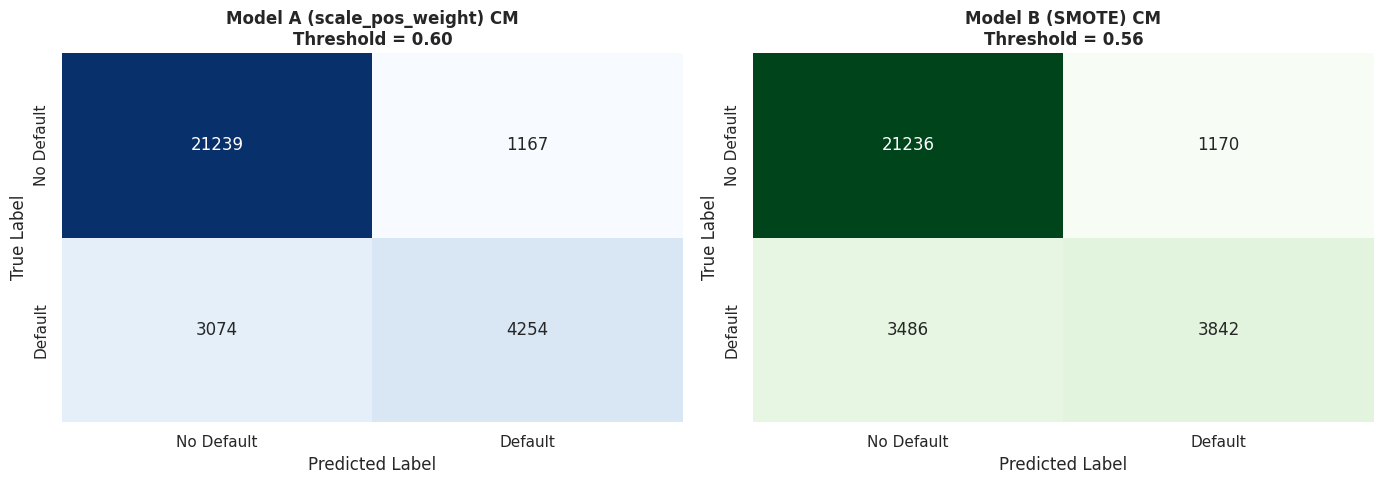


Model A (scale_pos_weight) Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22406
           1       0.78      0.58      0.67      7328

    accuracy                           0.86     29734
   macro avg       0.83      0.76      0.79     29734
weighted avg       0.85      0.86      0.85     29734


Model B (SMOTE) Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     22406
           1       0.77      0.52      0.62      7328

    accuracy                           0.84     29734
   macro avg       0.81      0.74      0.76     29734
weighted avg       0.84      0.84      0.83     29734



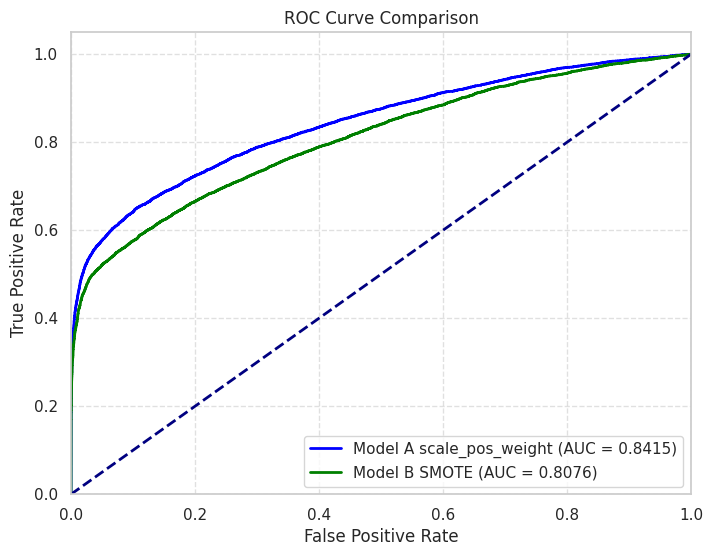

SUMMARY METRICS COMPARISON (Optimal Thresholds)
Model A (scale_pos_weight):
  AUC-ROC:   0.8415
  Threshold: 0.60
  Precision: 0.7847
  Recall:    0.5805
  F1-Score:  0.6673

Model B (SMOTE):
  AUC-ROC:   0.8076
  Threshold: 0.56
  Precision: 0.7666
  Recall:    0.5243
  F1-Score:  0.6227


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

y_scale_proba = best_model_scale.predict_proba(X_val)[:, 1]
y_smote_proba = best_model_smote.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_scale_f1 = 0.0
opt_scale_thresh = 0.5
for thresh in thresholds:
    score = f1_score(y_val, (y_scale_proba >= thresh).astype(int))
    if score > best_scale_f1:
        best_scale_f1 = score
        opt_scale_thresh = thresh

best_smote_f1 = 0.0
opt_smote_thresh = 0.5
for thresh in thresholds:
    score = f1_score(y_val, (y_smote_proba >= thresh).astype(int))
    if score > best_smote_f1:
        best_smote_f1 = score
        opt_smote_thresh = thresh

print(f"Model A (scale_pos_weight) Optimal Threshold: {opt_scale_thresh:.2f} | Best F1: {best_scale_f1:.4f}")
print(f"Model B (SMOTE) Optimal Threshold: {opt_smote_thresh:.2f} | Best F1: {best_smote_f1:.4f}")

y_pred_scale = (y_scale_proba >= opt_scale_thresh).astype(int)
y_pred_smote = (y_smote_proba >= opt_smote_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_scale = confusion_matrix(y_val, y_pred_scale)
sns.heatmap(cm_scale, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=axes[0])
axes[0].set_title(f'Model A (scale_pos_weight) CM\nThreshold = {opt_scale_thresh:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_smote = confusion_matrix(y_val, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=axes[1])
axes[1].set_title(f'Model B (SMOTE) CM\nThreshold = {opt_smote_thresh:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nModel A (scale_pos_weight) Classification Report:")
print(classification_report(y_val, y_pred_scale))

print("\nModel B (SMOTE) Classification Report:")
print(classification_report(y_val, y_pred_smote))

fpr_scale, tpr_scale, _ = roc_curve(y_val, y_scale_proba)
auc_scale = auc(fpr_scale, tpr_scale)

fpr_smote, tpr_smote, _ = roc_curve(y_val, y_smote_proba)
auc_smote = auc(fpr_smote, tpr_smote)

plt.figure(figsize=(8, 6))
plt.plot(fpr_scale, tpr_scale, color='blue', lw=2, label=f'Model A scale_pos_weight (AUC = {auc_scale:.4f})')
plt.plot(fpr_smote, tpr_smote, color='green', lw=2, label=f'Model B SMOTE (AUC = {auc_smote:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("="*50)
print("SUMMARY METRICS COMPARISON (Optimal Thresholds)")
print("="*50)
print(f"Model A (scale_pos_weight):")
print(f"  AUC-ROC:   {auc_scale:.4f}")
print(f"  Threshold: {opt_scale_thresh:.2f}")
print(f"  Precision: {precision_score(y_val, y_pred_scale):.4f}")
print(f"  Recall:    {recall_score(y_val, y_pred_scale):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_pred_scale):.4f}")
print(f"\nModel B (SMOTE):")
print(f"  AUC-ROC:   {auc_smote:.4f}")
print(f"  Threshold: {opt_smote_thresh:.2f}")
print(f"  Precision: {precision_score(y_val, y_pred_smote):.4f}")
print(f"  Recall:    {recall_score(y_val, y_pred_smote):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_pred_smote):.4f}")
print("="*50)


# Step 10 — Interpretability (SHAP)

We use SHAP (`TreeExplainer`) on the model that achieves the higher AUC-ROC on the validation set. We plot global feature importance (SHAP bar summary) and directional impact (SHAP beeswarm plot).


Explaining the higher-performing model (based on AUC-ROC)...



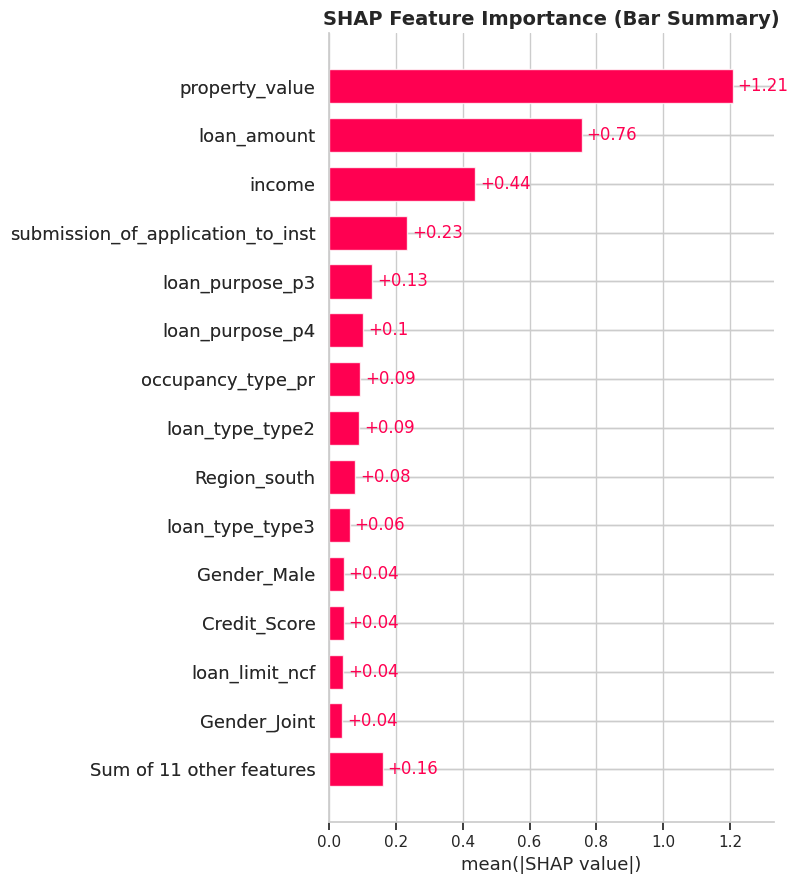

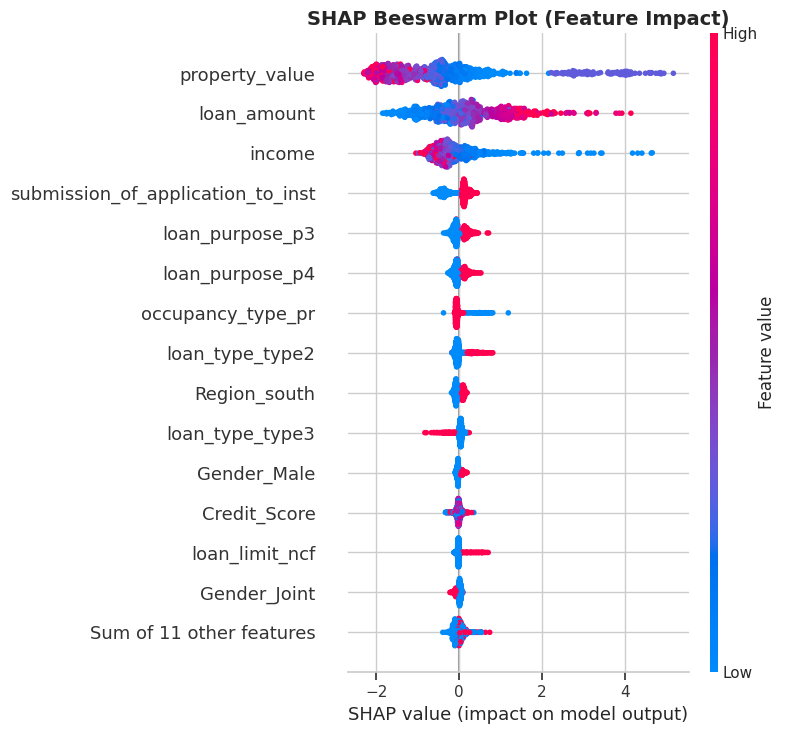

In [27]:
import shap

best_model = best_model_scale if auc_scale >= auc_smote else best_model_smote
print(f"Explaining the higher-performing model (based on AUC-ROC)...\n")

explainer = shap.TreeExplainer(best_model)
X_val_sample = X_val.sample(n=min(1000, len(X_val)), random_state=42)
shap_values = explainer(X_val_sample)

plt.figure(figsize=(8, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Summary)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot (Feature Impact)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
